# Telco Customer Churn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
telecom_cust = pd.read_csv("Telco-Customer-Churn.csv")

print("First ten rows:")
display(telecom_cust.head(10))

print("Column names:")
print(telecom_cust.columns.tolist())

print("Data types:")
print(telecom_cust.dtypes)

First ten rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [3]:
telecom_cust["TotalCharges"] = pd.to_numeric(telecom_cust["TotalCharges"], errors="coerce")
telecom_cust = telecom_cust.dropna().copy()
telecom_cust = telecom_cust.drop(columns="customerID")
telecom_cust["Churn"] = telecom_cust["Churn"].replace({"Yes": 1, "No": 0}).astype(int)

telecom_cust_dummies = pd.get_dummies(telecom_cust, drop_first=True, dtype=int)
telecom_cust_dummies.head()

C:\Users\thena\AppData\Local\Temp\ipykernel_25896\3389108676.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telecom_cust["Churn"] = telecom_cust["Churn"].replace({"Yes": 1, "No": 0}).astype(int)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


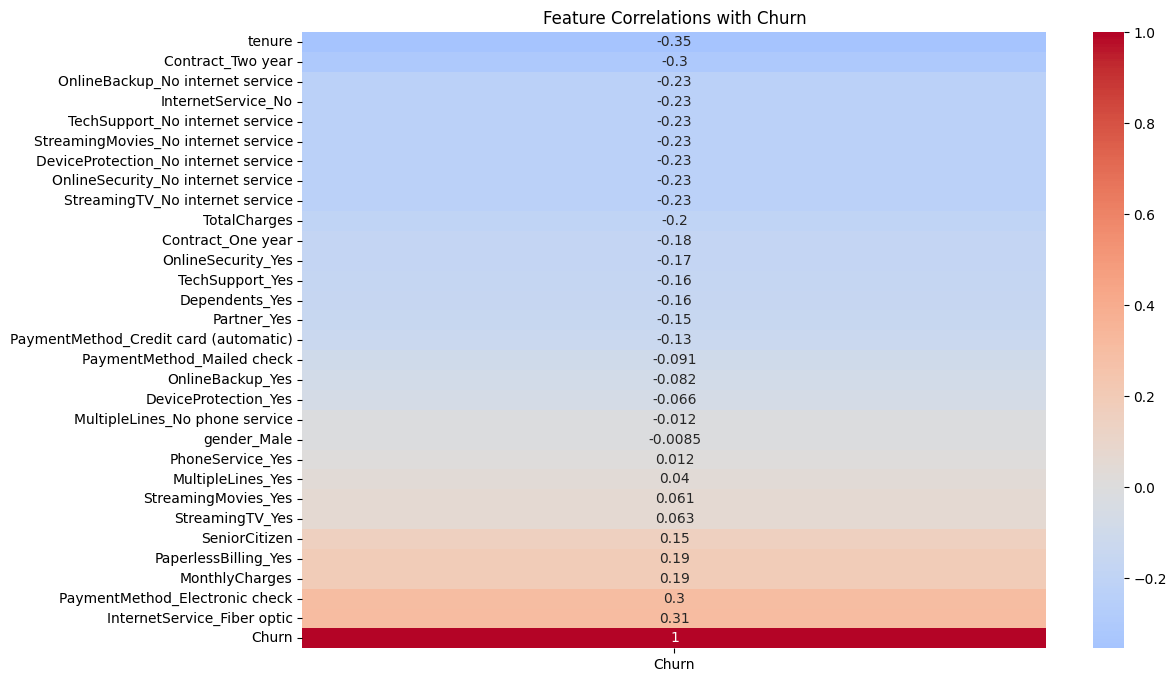

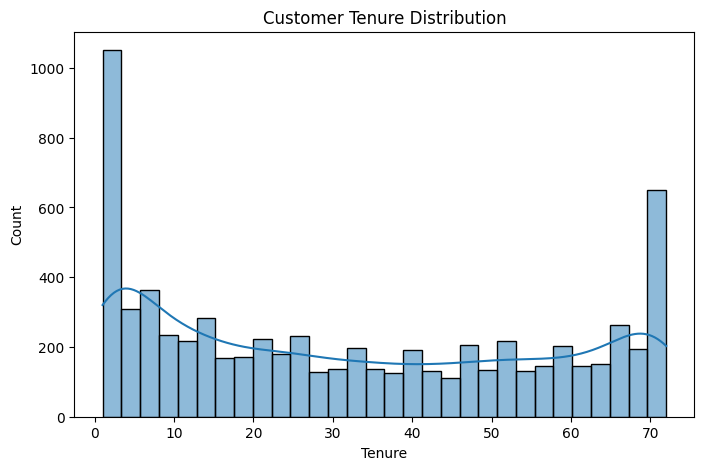

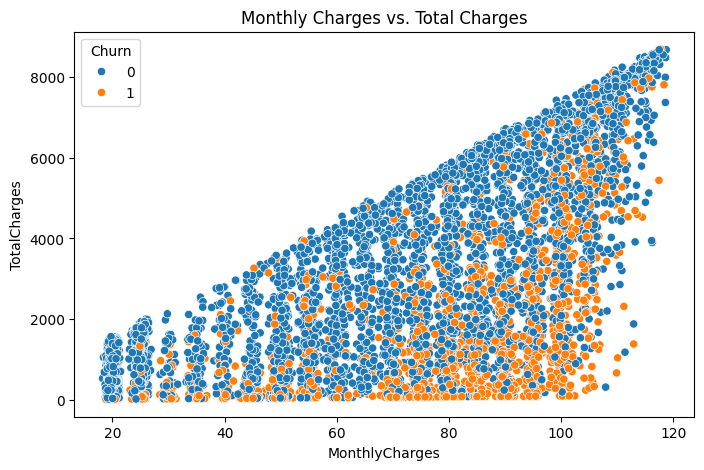

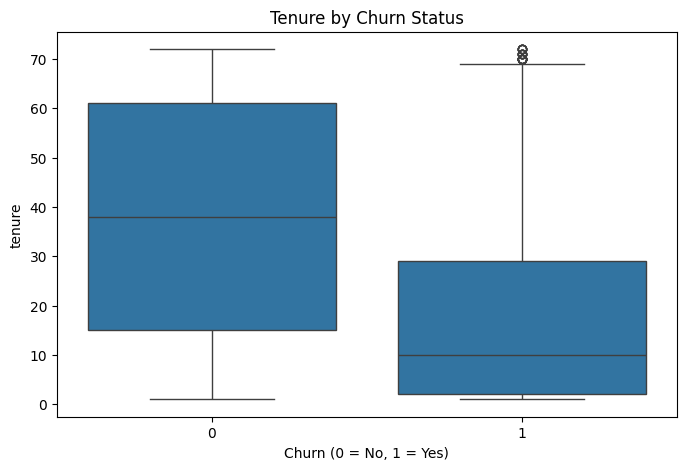

In [4]:
plt.figure(figsize=(12, 8))
sns.heatmap(telecom_cust_dummies.corr()[["Churn"]].sort_values("Churn"), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlations with Churn")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(telecom_cust["tenure"], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=telecom_cust, x="MonthlyCharges", y="TotalCharges", hue="Churn")
plt.title("Monthly Charges vs. Total Charges")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=telecom_cust, x="Churn", y="tenure")
plt.title("Tenure by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.show()

In [5]:
X = telecom_cust_dummies.drop(columns="Churn")
y = telecom_cust_dummies["Churn"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 5274
Test samples: 1758


In [6]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
print("Logistic regression accuracy:", logistic_accuracy)

random_forest_model = RandomForestClassifier(
    n_estimators=2000,
    oob_score=True,
    max_features="sqrt",
    max_leaf_nodes=50,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
random_forest_model.fit(X_train, y_train)
random_forest_predictions = random_forest_model.predict(X_test)
random_forest_accuracy = accuracy_score(y_test, random_forest_predictions)
random_forest_oob_error = 1 - random_forest_model.oob_score_
print("Random forest accuracy:", random_forest_accuracy)
print("Random forest OOB error:", random_forest_oob_error)

model_results = {}
for model_name, predictions in {
    "Logistic regression": logistic_predictions,
    "Random forest": random_forest_predictions,
}.items():
    matrix = confusion_matrix(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    model_results[model_name] = {"precision": precision, "recall": recall}
    print(f"\n{model_name} confusion matrix (rows = actual, columns = predicted):")
    print(matrix)
    print(f"{model_name} precision: {precision}")
    print(f"{model_name} recall: {recall}")

print("\nThe confusion matrices show true negatives, false positives, false negatives, and true positives.")
print("For churn retention, recall is especially important because false negatives are missed churners.")
best_model = max(model_results, key=lambda name: (model_results[name]["recall"], model_results[name]["precision"]))
print(f"Based on recall first, {best_model} is more suitable for prioritising churn retention.")

Logistic regression accuracy: 0.8060295790671217
Random forest accuracy: 0.7918088737201365
Random forest OOB error: 0.2007963594994312

Logistic regression confusion matrix (rows = actual, columns = predicted):
[[1150  141]
 [ 200  267]]
Logistic regression precision: 0.6544117647058824
Logistic regression recall: 0.5717344753747323

Random forest confusion matrix (rows = actual, columns = predicted):
[[1174  117]
 [ 249  218]]
Random forest precision: 0.6507462686567164
Random forest recall: 0.4668094218415418

The confusion matrices show true negatives, false positives, false negatives, and true positives.
For churn retention, recall is especially important because false negatives are missed churners.
Based on recall first, Logistic regression is more suitable for prioritising churn retention.
